<a href="https://colab.research.google.com/github/YoshnaM/6CS012-Artificial-Intelligence-and-Machine-Learning/blob/main/YoshnaMaharjan_2406791_Worksheet06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Worksheet 06

#Task 1:
Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.

*   Use Data Augmentation to increase the number of training image.

*   Use deeper model with BN and DropOut layer as presented above.

*   Understand the Model Summary and Training Behavior.

#Setup & Dataset Extraction

###Import Libraries:

In [1]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report

###Extract Dataset:

In [2]:
zip_path = "/content/drive/MyDrive/Artificial_Intelligence_And_Machine_Learning/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

if not os.path.exists(extract_path):
    print("Extracting dataset.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already exists.")

Extracting dataset.
Dataset extracted successfully!


###Locate Train and Test Directories:

In [3]:
def find_folder(base_dir, target_name):
    for root, dirs, files in os.walk(base_dir):
        if target_name in dirs:
            return os.path.join(root, target_name)

train_dir = find_folder(extract_path, "train")
test_dir = find_folder(extract_path, "test")

print(f"Train Directory: {train_dir}")
print(f"Test Directory: {test_dir}")

Train Directory: /content/FruitinAmazon/FruitinAmazon/train
Test Directory: /content/FruitinAmazon/FruitinAmazon/test


#Data Understanding & Visualization

###Read Dataset Directory:

In [4]:
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


###Check Corrupted Images:

In [5]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


###Check Class Balance:

In [6]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("="*45)
print(f"{'Class Name':<25}{'Count':>15}")
print("="*45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("="*45)


Class Distribution:
Class Name                         Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


###Random Image Visualization:

In [7]:
selected_images = []    # Store image paths
selected_labels = []    # Store corresponding class names

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if images:  # Ensure the class folder is not empty
            img_path = os.path.join(class_path, random.choice(images))
            selected_images.append(img_path)
            selected_labels.append(class_name)

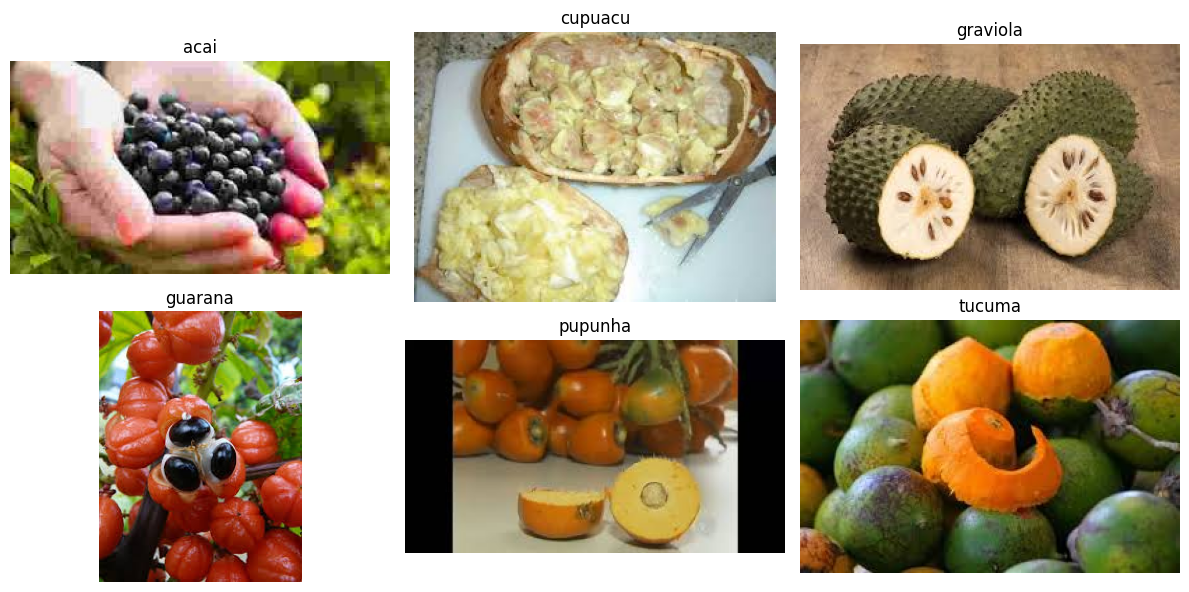

In [8]:
# Plot Images
cols = (len(selected_images) + 1) // 2  # Determine columns
rows = 2    # Fixed rows for layout

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < len(selected_images):
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.tight_layout()
plt.show()

#Data Generation & Preprocessing

###Create Train & Validation Dataset:

In [9]:
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


###Check Dataset Shape:

In [10]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


###Visualize Dataset:

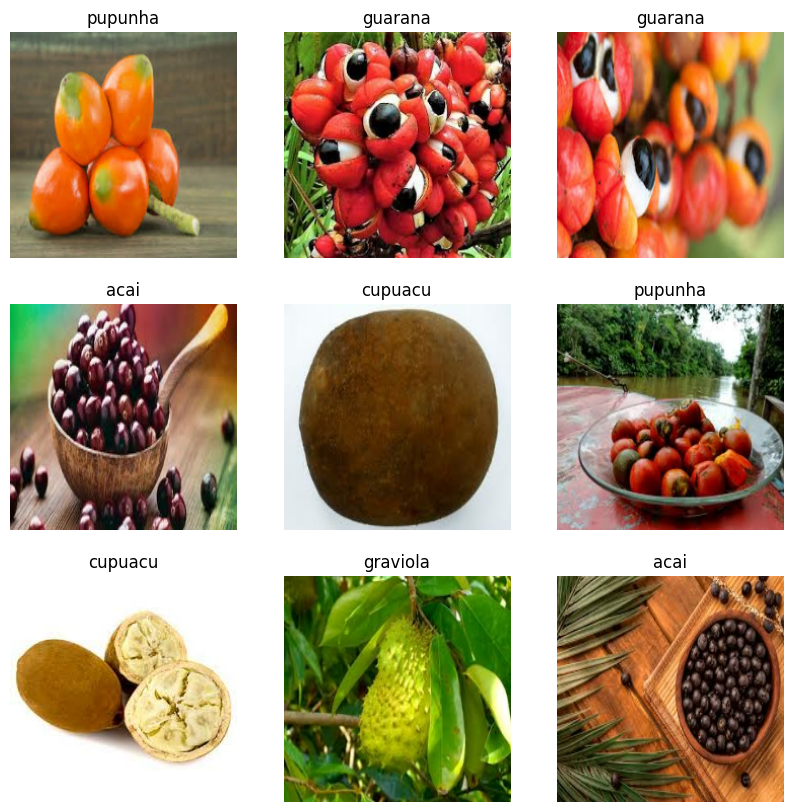

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        class_name = class_names[int(labels[i])]
        plt.title(class_name)

        plt.axis("off")

###Data Augmentation:

In [12]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

###Visualize Augmented Images:

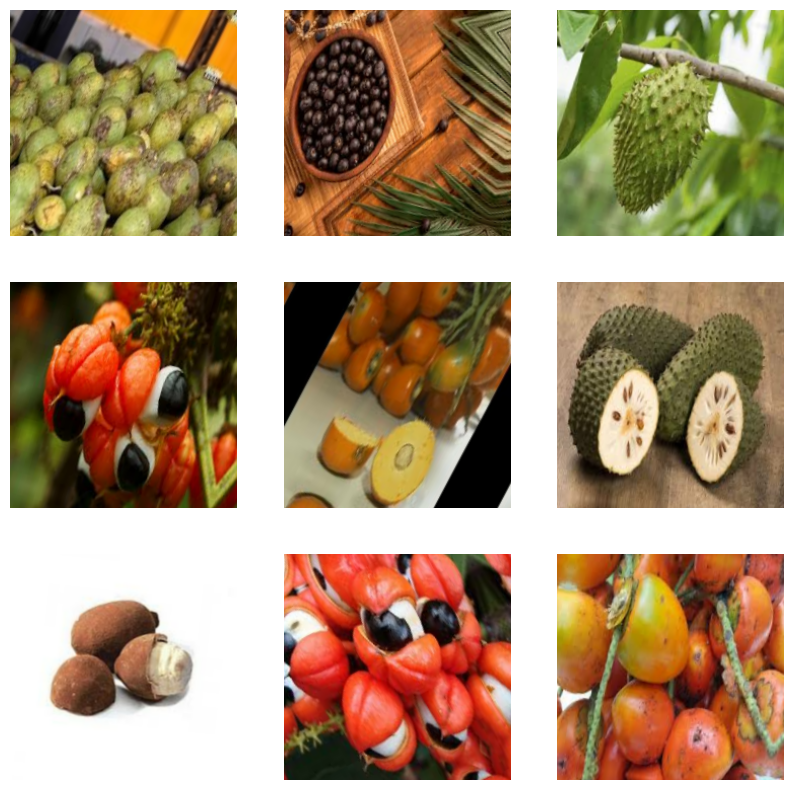

In [13]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

###Build a Deeper CNN Model (Batch Normalization and Dropout):

In [14]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Augmentation + Rescaling
    layers.Lambda(data_augmentation),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Dense Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output
    layers.Dense(len(class_names), activation='softmax')
])

###Compile Model:

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

###Model Summary:

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

###Define Callbacks:

In [17]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
]

###Train Model:

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1157 - loss: 2.5138
Epoch 1: val_loss improved from None to 1.90616, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.0972 - loss: 2.5541 - val_accuracy: 0.0556 - val_loss: 1.9062
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2361 - loss: 2.6317
Epoch 2: val_loss improved from 1.90616 to 1.85167, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.2083 - loss: 2.7076 - val_accuracy: 0.0556 - val_loss: 1.8517
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1956 - loss: 2.4419
Epoch 3: val_loss improved from 1.85167 to 1.80469, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - accuracy: 0.1806 - loss: 2.4290 - val_accuracy: 0.1667 - val_loss: 1.8047
Epoch 4/20

###Evaluate model:

In [19]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 1.8047
Validation Accuracy: 0.1667


#Task 2:
*   Implement transfer learning using a pre-trained model trained on ImageNet weights, freeze the layers of the model, and fit it only on the output layer to classify the fruits dataset.

*   Evaluate the model's performance and generate an inference output and classification report.

*   Did the performance improved compared to training from scratch.

###Load Pretrained Model:

In [20]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Freeze Layers:

In [21]:
for layer in base_model.layers:
    layer.trainable = False

###Add Custom Layers:

In [22]:
# Add custom layers on top of the pre-trained model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  # Reduces dimensions (height, width) to a single vector per image
x = layers.Dense(1024, activation='relu')(x)    # Fully connected layer with 1024 neurons
outputs = layers.Dense(len(class_names), activation='softmax')(x)   # Output layer for 10 classes (with softmax for multi-class classification)

###Final Model:

In [23]:
model_tl = Model(inputs=base_model.input, outputs=outputs)

###Compile Model:

In [24]:
model_tl.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

###Train Model:

In [25]:
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.2338 - loss: 7.3598 
Epoch 1: val_loss did not improve from 1.80469
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 0.2639 - loss: 7.3629 - val_accuracy: 0.4444 - val_loss: 9.2640
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7153 - loss: 4.3809 
Epoch 2: val_loss did not improve from 1.80469
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 22s/step - accuracy: 0.7083 - loss: 4.0582 - val_accuracy: 0.3889 - val_loss: 7.3990
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9803 - loss: 0.1908 
Epoch 3: val_loss did not improve from 1.80469
3/3 ━━━━━━━━━━━━━━━━━━━━ 87s 23s/step - accuracy: 0.9722 - loss: 0.2701 - val_accuracy: 0.3889 - val_loss: 7.0588
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9699 - loss: 0.1224 
Epoch 4: val_loss did not improve from 1.80469
3/3 ━━━━━━━━━━━━━━━━━━━━ 78s 23s/step - accuracy: 0.9722 - loss: 0.1226 - val_accuracy: 0.3889 - val_loss: 7.8342
Epoch 5/10
3/3 ━━━━━━━━━

###Save Model:

In [26]:
model_tl.save("/content/vgg16_model.keras")

###Evaluate Model:

In [27]:
loss, acc = model_tl.evaluate(val_ds)
print(f"Transfer Learning Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.4444 - loss: 9.2640
Transfer Learning Accuracy: 0.4444


###Predictions:

In [28]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_tl.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Sample Predictions:", y_pred[:10])
print("Actual Labels:     ", y_true[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Sample Predictions: [5 2 1 5 1 5 5 3 3 3]
Actual Labels:      [4 4 1 5 1 0 1 5 3 0]


###Classification Report:

In [29]:
print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       1.00      0.75      0.86         4
    graviola       0.33      1.00      0.50         1
     guarana       0.20      1.00      0.33         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.43      0.60      0.50         5

    accuracy                           0.44        18
   macro avg       0.33      0.56      0.37        18
weighted avg       0.37      0.44      0.38        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
print("MODEL PERFORMANCE COMPARISON")

cnn_loss, cnn_acc = model.evaluate(val_ds)
tl_loss, tl_acc = model_tl.evaluate(val_ds)

print(f"CNN from scratch accuracy: {cnn_acc:.4f}")
print(f"VGG16 Transfer Learning accuracy: {tl_acc:.4f}")

if tl_acc > cnn_acc:
    print("\n Transfer Learning performed better")
else:
    print("\n CNN performed better (unusual case due to dataset size)")

MODEL PERFORMANCE COMPARISON
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step - accuracy: 0.1667 - loss: 1.8047
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.4444 - loss: 9.2640
CNN from scratch accuracy: 0.1667
VGG16 Transfer Learning accuracy: 0.4444

 Transfer Learning performed better
